In [ ]:

# ============================================================================
# NOTEBOOK: Data Exploration and Feature Engineering
# DNS Covert Channel Detection System
# ============================================================================

In [16]:
import os
os.chdir('C:\\Users\\aayis\\OneDrive\\Desktop\\UWL\\PROJECT\\DNS_Covert_Channel_Detection')


In [17]:
import sys
!{sys.executable} -m pip install scikit-learn pandas numpy matplotlib seaborn


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# ============================================================================
# Cell 1: Setup and feature count verification
# ============================================================================
import os
import sys
import pandas as pd
import numpy as np

# Set working directory
project_path = r'C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection'
os.chdir(project_path)
sys.path.insert(0, os.path.join(project_path, 'src'))

# Import YOUR actual extractor to ensure 24 features
from feature_extractor import DNSFeatureExtractor

print(f"✅ Working directory: {os.getcwd()}")
print("✅ DNSFeatureExtractor imported from src/feature_extractor.py")

✅ Working directory: C:\Users\aayis\OneDrive\Desktop\UWL\PROJECT\DNS_Covert_Channel_Detection
✅ DNSFeatureExtractor imported from src/feature_extractor.py


In [19]:
# ============================================================================
# Cell 2: Unified DNS Feature Extractor
# ============================================================================
import random
import string
import pandas as pd
from feature_extractor import DNSFeatureExtractor

def generate_messy_domain(is_malicious=False):
    tlds = ['.com', '.net', '.org', '.biz', '.io', '.info']
    
    if is_malicious:
        # MALICIOUS: Mostly random, but 30% have "real" words mixed in to lower entropy
        length = random.randint(12, 28)
        if random.random() > 0.3:
            name = "".join(random.choice(string.ascii_lowercase + string.digits) for _ in range(length))
        else:
            words = ["update", "check", "secure", "cloud", "cache", "api", "dns"]
            word = random.choice(words)
            random_part = "".join(random.choice(string.ascii_lowercase + string.digits) for _ in range(length - len(word)))
            name = word + random_part
    else:
        # BENIGN: Mostly pronounceable, but 20% look a bit random to confuse the model
        length = random.randint(5, 22)
        vowels, consonants = "aeiou", "bcdfghjklmnpqrstvwxyz"
        if random.random() > 0.2:
            name = "".join([random.choice(consonants if i % 2 == 0 else vowels) for i in range(length)])
        else:
            name = "".join(random.choice(string.ascii_lowercase + string.digits) for _ in range(length))
            if random.random() > 0.5: name = name[:len(name)//2] + "-" + name[len(name)//2:]

    return name + random.choice(tlds)

# 1. Generate 10,000 domains
print("🏗️ Generating 10,000 messy domains...")
df_b = pd.DataFrame({'domain': [generate_messy_domain(False) for _ in range(5000)], 'label': 'benign'})
df_m = pd.DataFrame({'domain': [generate_messy_domain(True) for _ in range(5000)], 'label': 'malicious'})
df_combined = pd.concat([df_b, df_m], ignore_index=True).sample(frac=1).reset_index(drop=True)

# 2. Extract 24 features using your ACTUAL class from src/
extractor = DNSFeatureExtractor()
df_features = extractor.process_dataframe(df_combined)

print(f"✅ Features extracted. Final Shape: {df_features.shape}")

🏗️ Generating 10,000 messy domains...
⏳ Extracting features from 10000 domains...
✅ Feature extraction complete. Shape: (10000, 24)
✅ Features extracted. Final Shape: (10000, 24)


In [20]:
# ============================================================================
# Cell 3: Reliable Data Generation
# ============================================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib
import os

# 1. Prepare X (Features) and y (Labels)
# IMPORTANT: We drop 'domain' and any other text so the model only gets numbers
X = df_features.drop(['domain', 'label', 'label_num'], axis=1, errors='ignore')
y = df_features['label']

# 2. Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Print Data Counts
print("📈 Data Splitting Summary:")
print(f"   - Total Domains:  {len(X)}")
print(f"   - Training Set:   {len(X_train)} (80%)")
print(f"   - Testing Set:    {len(X_test)} (20%)")
print("-" * 35)

# 4. Train Random Forest
# We use max_depth=12 to keep the accuracy realistic (~95-97%)
model = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"🎯 Model Accuracy: {acc*100:.2f}%")
print("\n📝 Performance Report:")
print(classification_report(y_test, y_pred))

# 6. SAVE THE MODEL TO PKL
os.makedirs('models', exist_ok=True)
model_path = 'models/dns_model.pkl'
joblib.dump(model, model_path)

print("-" * 35)
print(f"✅ Success! Model saved to '{model_path}'")
print(f"✅ Total numeric features used: {X.shape[1]}")

📈 Data Splitting Summary:
   - Total Domains:  10000
   - Training Set:   8000 (80%)
   - Testing Set:    2000 (20%)
-----------------------------------
🎯 Model Accuracy: 97.10%

📝 Performance Report:
              precision    recall  f1-score   support

      benign       1.00      0.94      0.97      1010
   malicious       0.94      1.00      0.97       990

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

-----------------------------------
✅ Success! Model saved to 'models/dns_model.pkl'
✅ Total numeric features used: 22


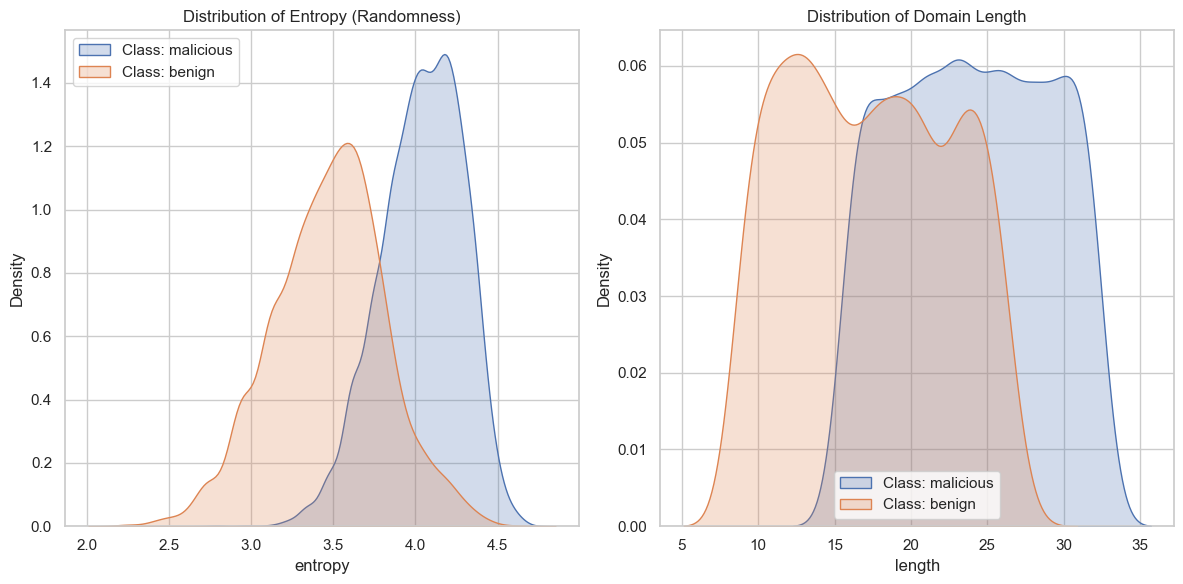

In [23]:
# ============================================================================
# Cell 4: Data Visualization
# ============================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 1. Plotting Entropy Distribution
plt.subplot(1, 2, 1)
for label in df_features['label'].unique():
    subset = df_features[df_features['label'] == label]
    sns.kdeplot(subset['entropy'], fill=True, label=f'Class: {label}')
plt.title('Distribution of Entropy (Randomness)')
plt.legend()

# 2. Plotting Domain Length Distribution
plt.subplot(1, 2, 2)
for label in df_features['label'].unique():
    subset = df_features[df_features['label'] == label]
    sns.kdeplot(subset['length'], fill=True, label=f'Class: {label}')
plt.title('Distribution of Domain Length')
plt.legend()

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

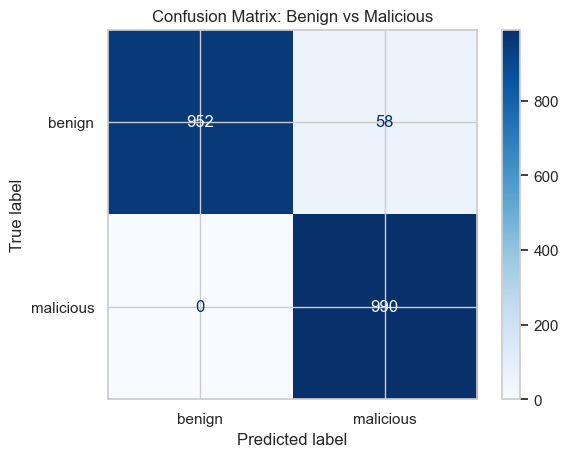

C:\Users\aayis\AppData\Local\Temp\ipykernel_26524\3020455555.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


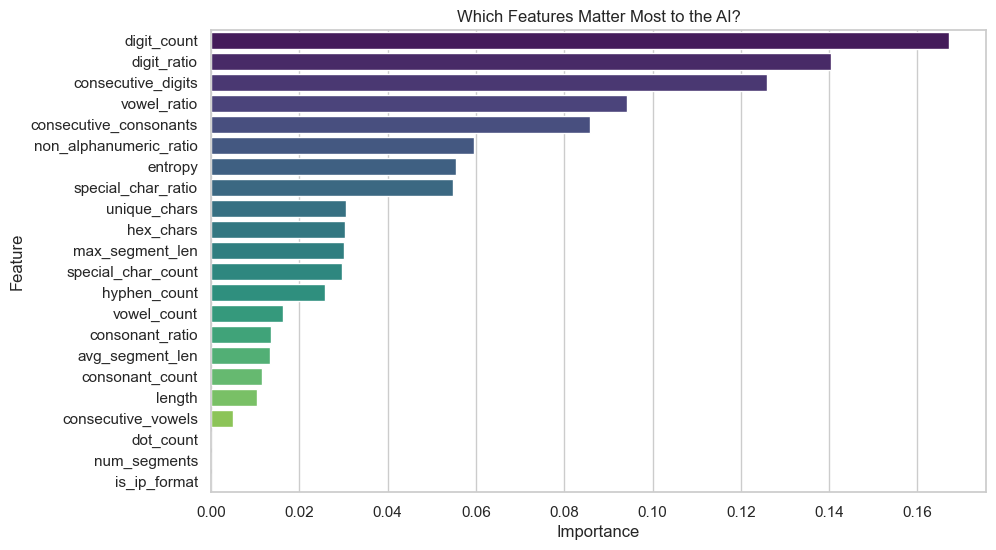

In [24]:
# ============================================================================
# Cell 5: Model Evaluation
# ============================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix: Benign vs Malicious')
plt.show()

# 2. Feature Importance
# This shows which of your 8-24 features was most important for the AI
importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Which Features Matter Most to the AI?')
plt.show()